In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# df = pd.read_csv('Backups/Backup_old_scaler/grid_search.csv')
df = pd.read_csv('grid_search.csv')


In [6]:
df[df['error'] == 1].groupby('train_samples')['error'].sum()

Series([], Name: error, dtype: int64)

In [4]:
print(f'Всего было {df.shape[0]} запусков из которых {df[df["error"] == 0].shape[0]} завершились успешно')

Всего было 18 запусков из которых 18 завершились успешно


Результат с лучшими параметрами по каждой из метрик

In [5]:
df[df['ci_train_same_size'] == df['ci_train_same_size'].max()]

,train_samples,test_samples,method,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
12,15,1,LogReg_Classic,0.944248,0.944093,0.953116,0.200481,0.194006,0.333624,7.307478,1.104938,0,NaN,5
13,15,10,LogReg_Classic,0.944248,0.944093,0.947177,0.200481,0.194006,0.205927,7.307478,9.436111,0,NaN,5
14,15,25,LogReg_Classic,0.944248,0.944093,0.947025,0.200481,0.194006,0.191119,7.307478,23.399270,0,NaN,5


In [6]:
df[df['ci_test'] == df['ci_test'].max()]

,train_samples,test_samples,method,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
12,15,1,LogReg_Classic,0.944248,0.944093,0.953116,0.200481,0.194006,0.333624,7.307478,1.104938,0,NaN,5


In [7]:
df[df['ibs_train_same_size'] == df['ibs_train_same_size'].min()]

,train_samples,test_samples,method,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
12,15,1,LogReg_Classic,0.944248,0.944093,0.953116,0.200481,0.194006,0.333624,7.307478,1.104938,0,NaN,5
13,15,10,LogReg_Classic,0.944248,0.944093,0.947177,0.200481,0.194006,0.205927,7.307478,9.436111,0,NaN,5
14,15,25,LogReg_Classic,0.944248,0.944093,0.947025,0.200481,0.194006,0.191119,7.307478,23.399270,0,NaN,5


In [8]:
df[(df['ibs_test'] == df['ibs_test'].min())]

,train_samples,test_samples,method,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
8,5,25,LogReg_Classic,0.943827,0.943319,0.945806,0.228968,0.196422,0.189354,2.575851,21.925342,0,NaN,3


# Графики

In [12]:
import matplotlib.pyplot as plt
def draw_pandas_plot(df, metric, ticks, test_samples=1, ax=None):
    # metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[metric].agg(['mean', 'min', 'max'])
    if not ax is None:
        ax.plot(metric_df)
        ax.set_yticks(ticks)
        ax.set_ylabel(metric)
        return 0
    return plt.plot(metric_df)

In [13]:
import matplotlib.pyplot as plt
def draw_all_metrics_plots(df_full, metric, ticks, full_metrics_name=None, method = None):
    if not method is None:
        df = df_full[df_full['method'] == method]
    else:
        df = df_full
        
    test_grid = df['test_samples'].dropna().unique()
    test_grid_sz = len(test_grid)
    
    fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
    fig.suptitle(f'Метрика {full_metrics_name if not full_metrics_name is None else metric}, модель {method}')

    metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean', 'min', 'max'])
    metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean'])
    ax[0].plot(metric_df, marker='.')
    ax[0].set_yticks(ticks)
    ax[0].set_xlabel('n_train')
    ax[0].set_title(f'С длиной цепочки n_train')

    ax[0].grid()

    metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean', 'min', 'max'])
    metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean'])
    ax[1].plot(metric_df, marker='.')
    ax[1].set_yticks(ticks)
    ax[1].set_title(f'C длиной цепочки максимального размера')
    ax[1].set_xlabel('n_train')
    ax[1].grid()
    
    for i, test_samples in enumerate(test_grid):
        metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean', 'min', 'max'])
        metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean'])
        ax[2].plot(metric_df, marker='.')
        ax[2].set_xlabel('n_train')
        ax[2].grid()
        
        ax[2].set_yticks(ticks)
    ax[2].set_title(f'Длина цепочки в тестовой выборке: {test_samples}')
    ax[2].legend([1, 10, 25], title='Длина цепочки')
    fig.savefig(f'fig_{metric}.jpg')

UnboundLocalError: local variable 'test_samples' referenced before assignment

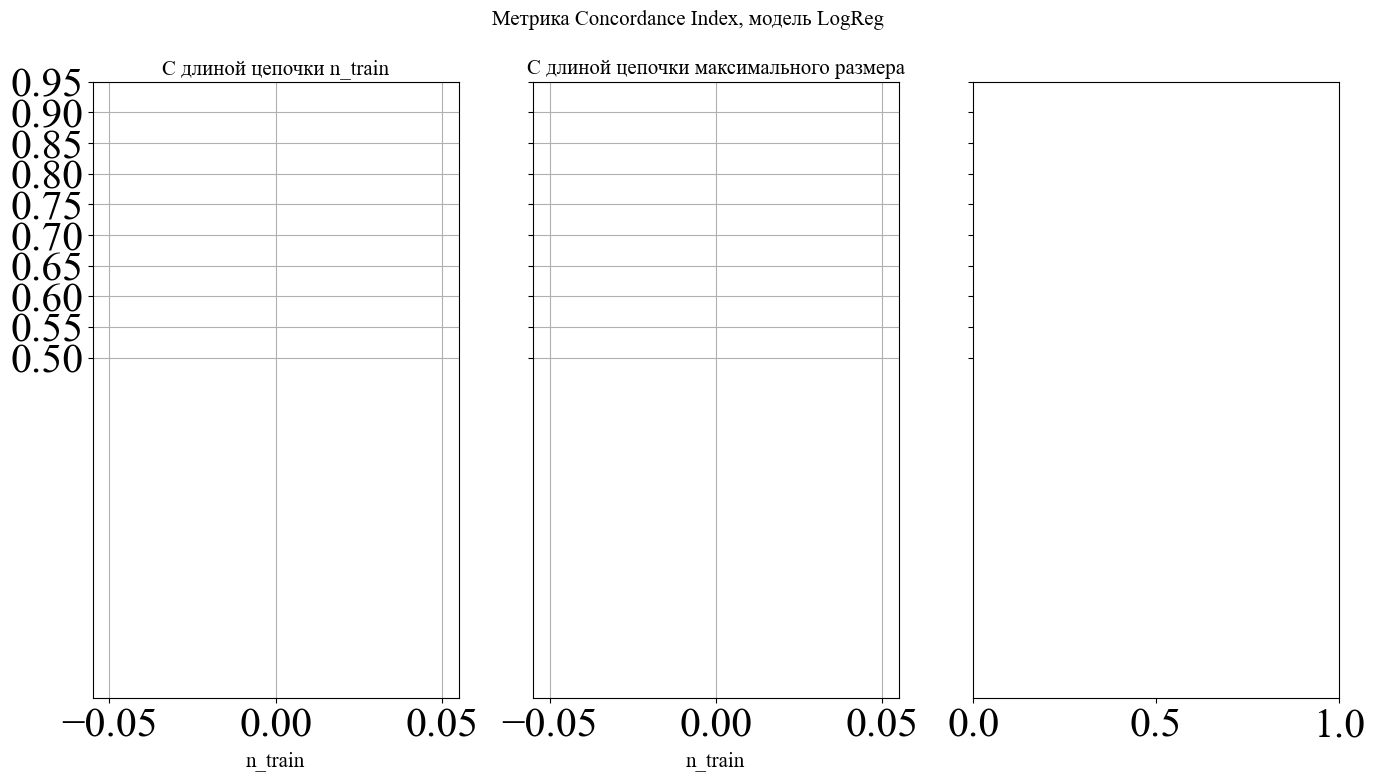

In [14]:
import matplotlib
plt.rcParams["figure.figsize"] = (14,8)
plt.rcParams["font.family"] = "Times New Roman"
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 15

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)    # fontsize of the tick labels
plt.rc('ytick', labelsize=30)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
draw_all_metrics_plots(df, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'LogReg')


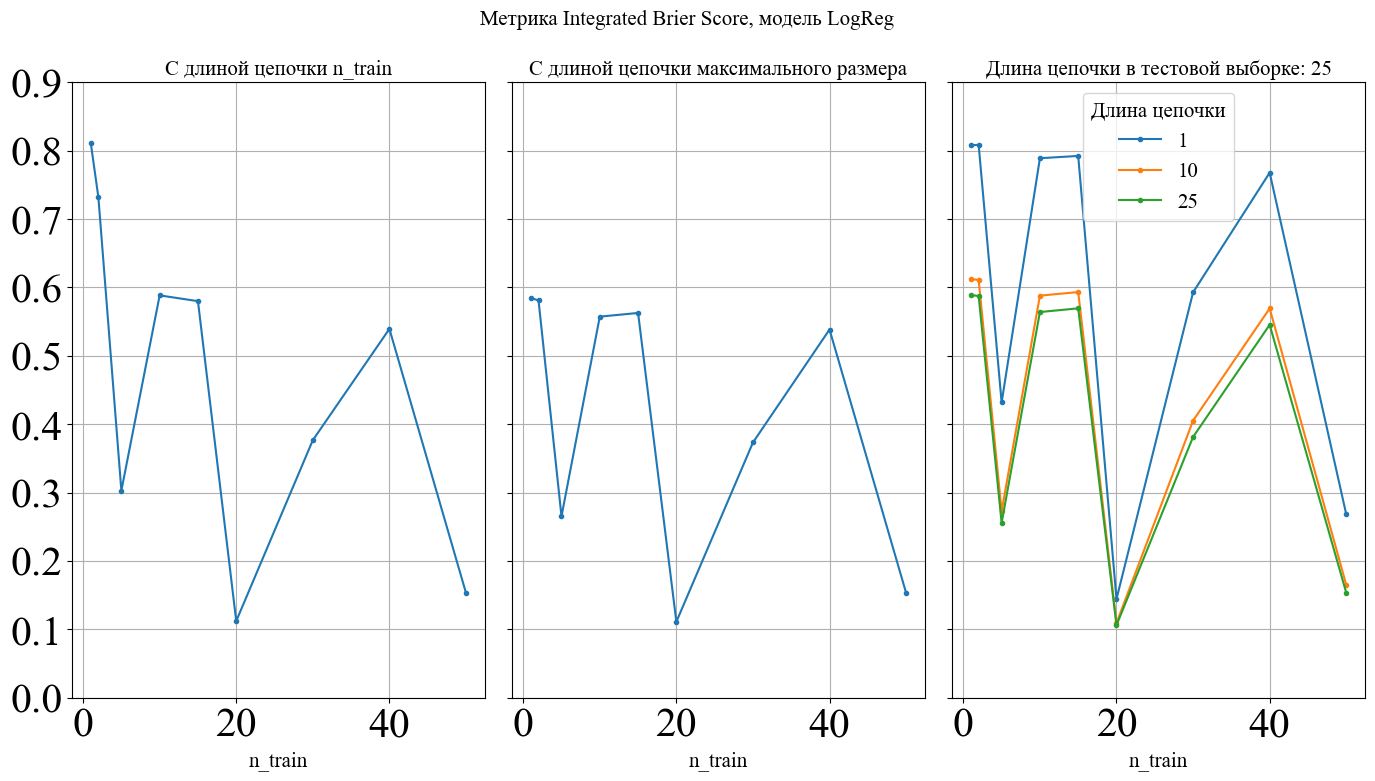

In [29]:
draw_all_metrics_plots(df, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='LogReg')

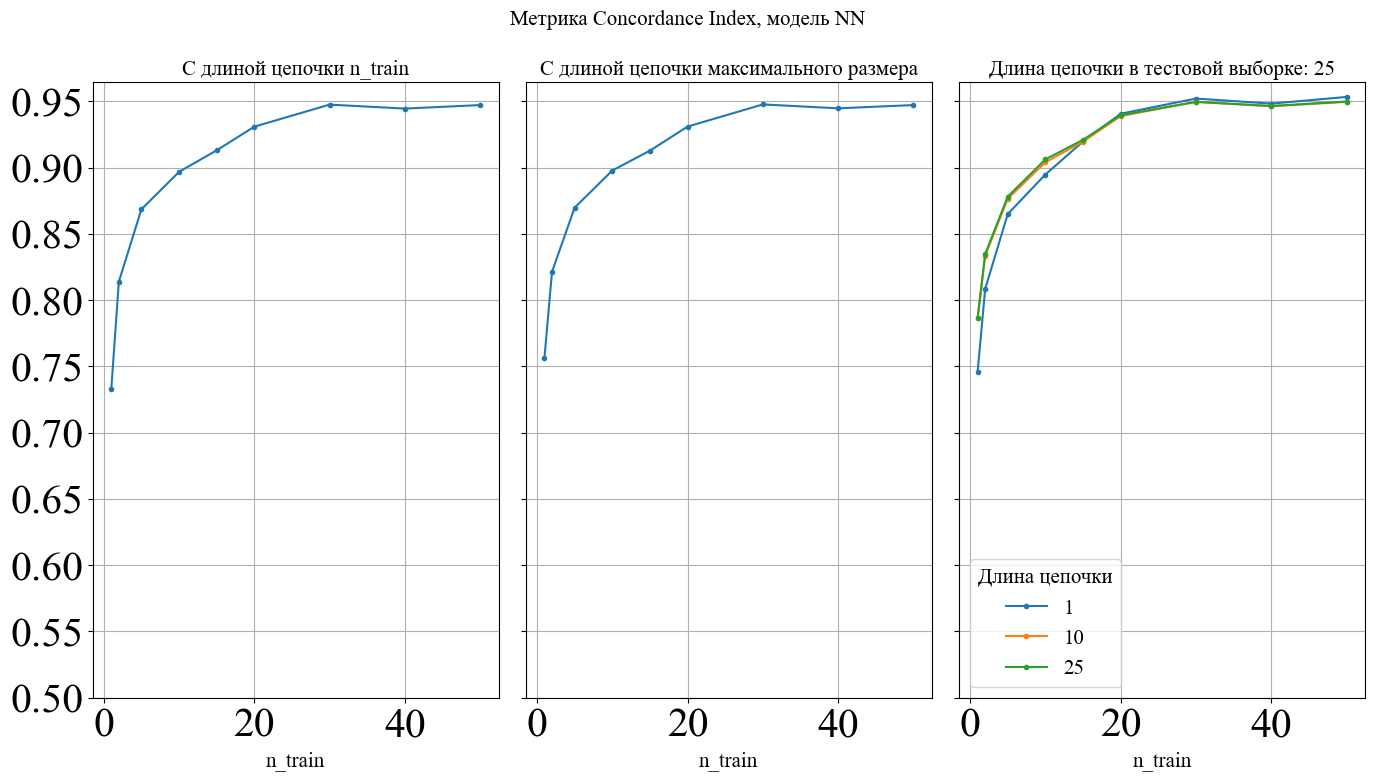

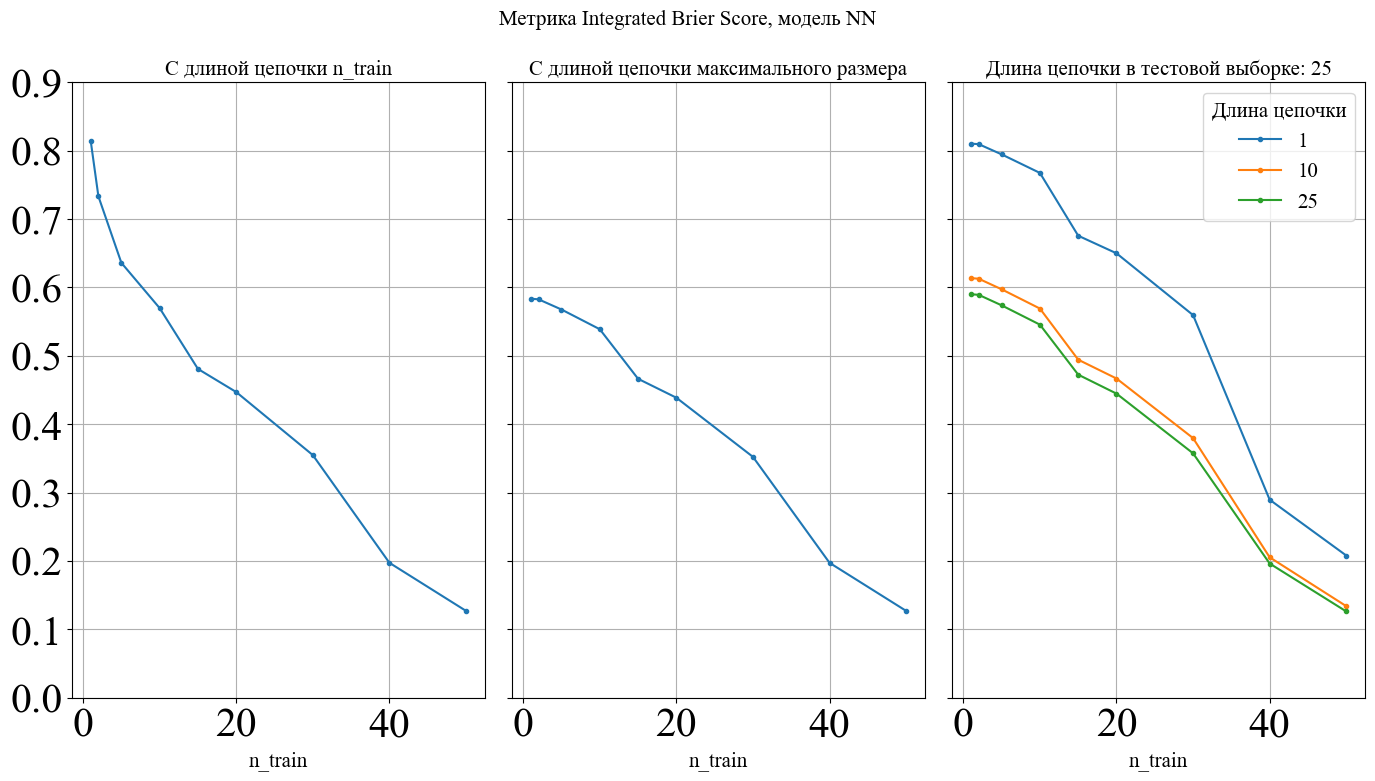

In [30]:
draw_all_metrics_plots(df, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'NN')
draw_all_metrics_plots(df, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='NN')


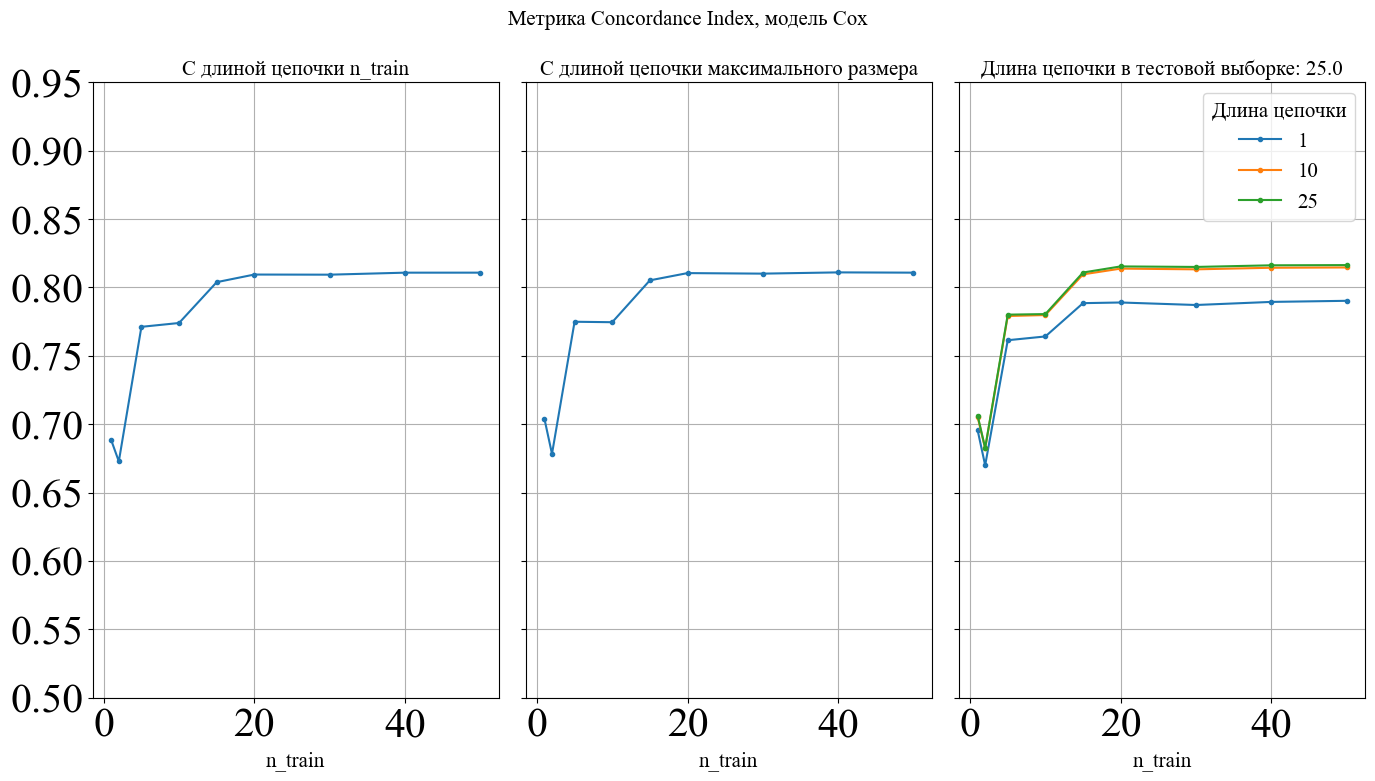

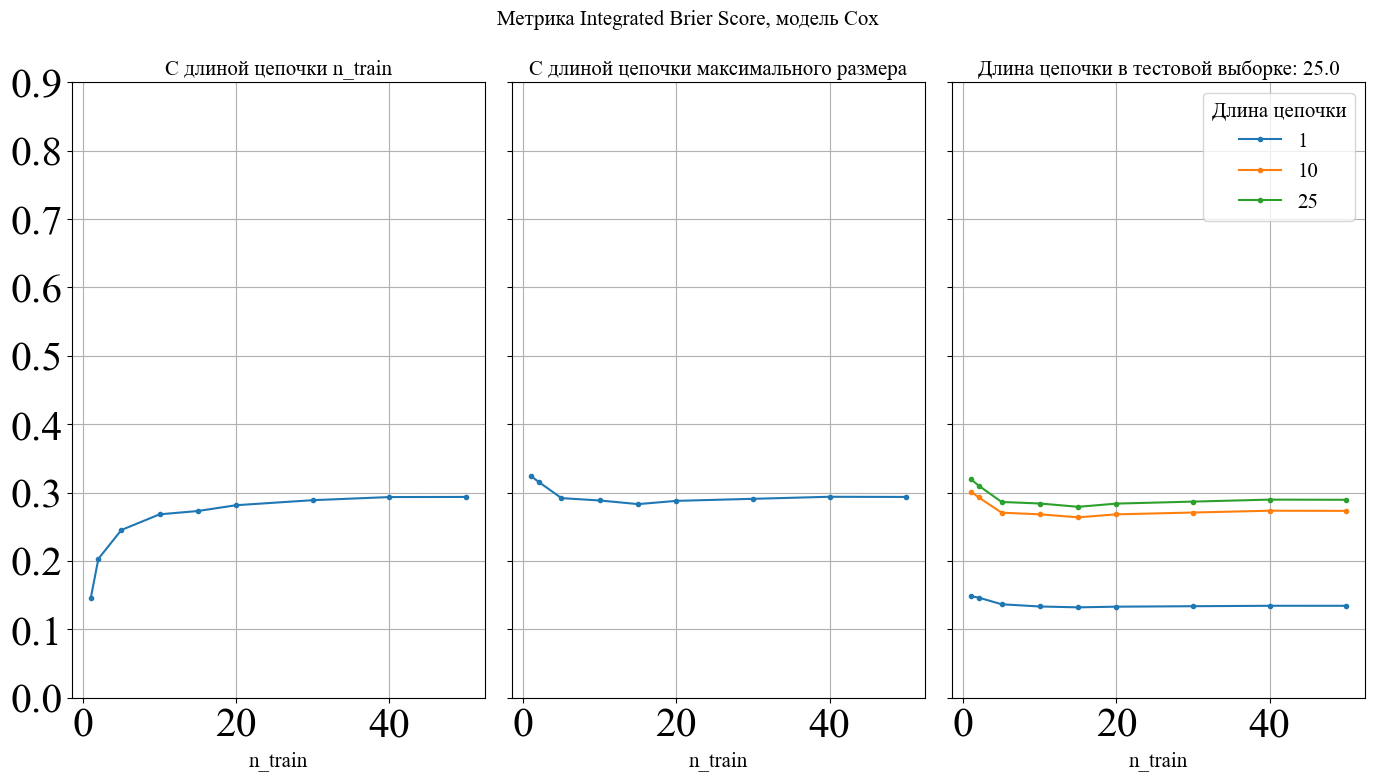

In [41]:
df_cox = pd.read_csv('grid_search_cox.csv')
draw_all_metrics_plots(df_cox, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'Cox')
draw_all_metrics_plots(df_cox, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='Cox')


In [4]:
def draw_all_metrics_agg(df_full, metric, ticks, full_metrics_name=None, method = None):
    if not method is None:
        df = df_full[df_full['method'] == method]
    else:
        df = df_full
        
    test_grid = df['test_samples'].dropna().unique()
    test_grid_sz = len(test_grid)
    
    fig, ax = plt.subplots(1, 2 + test_grid_sz, sharey=True, tight_layout=True)
    fig.suptitle(f'Метрика {full_metrics_name if not full_metrics_name is None else metric}, модель {method}')

    metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean', 'min', 'max'])
    ax[0].plot(metric_df, marker='.')
    ax[0].set_yticks(ticks)
    ax[0].set_xlabel('n_train')
    ax[0].set_title(f'С длиной цепочки n_train')

    ax[0].grid()

    metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean', 'min', 'max'])
    ax[1].plot(metric_df, marker='.')
    ax[1].set_yticks(ticks)
    ax[1].set_title(f'C длиной цепочки максимального размера')
    ax[1].set_xlabel('n_train')
    ax[1].grid()
    
    for i, test_samples in enumerate(test_grid):
        metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean', 'min', 'max'])
        ax[i + 2].plot(metric_df, marker='.')
        ax[i + 2].set_xlabel('n_train')
        ax[i + 2].grid()
        
        ax[i + 2].set_yticks(ticks)
        ax[i + 2].set_title(f'Длина цепочки в тестовой выборке: {test_samples}')
    fig.savefig(f'fig_{metric}.jpg')

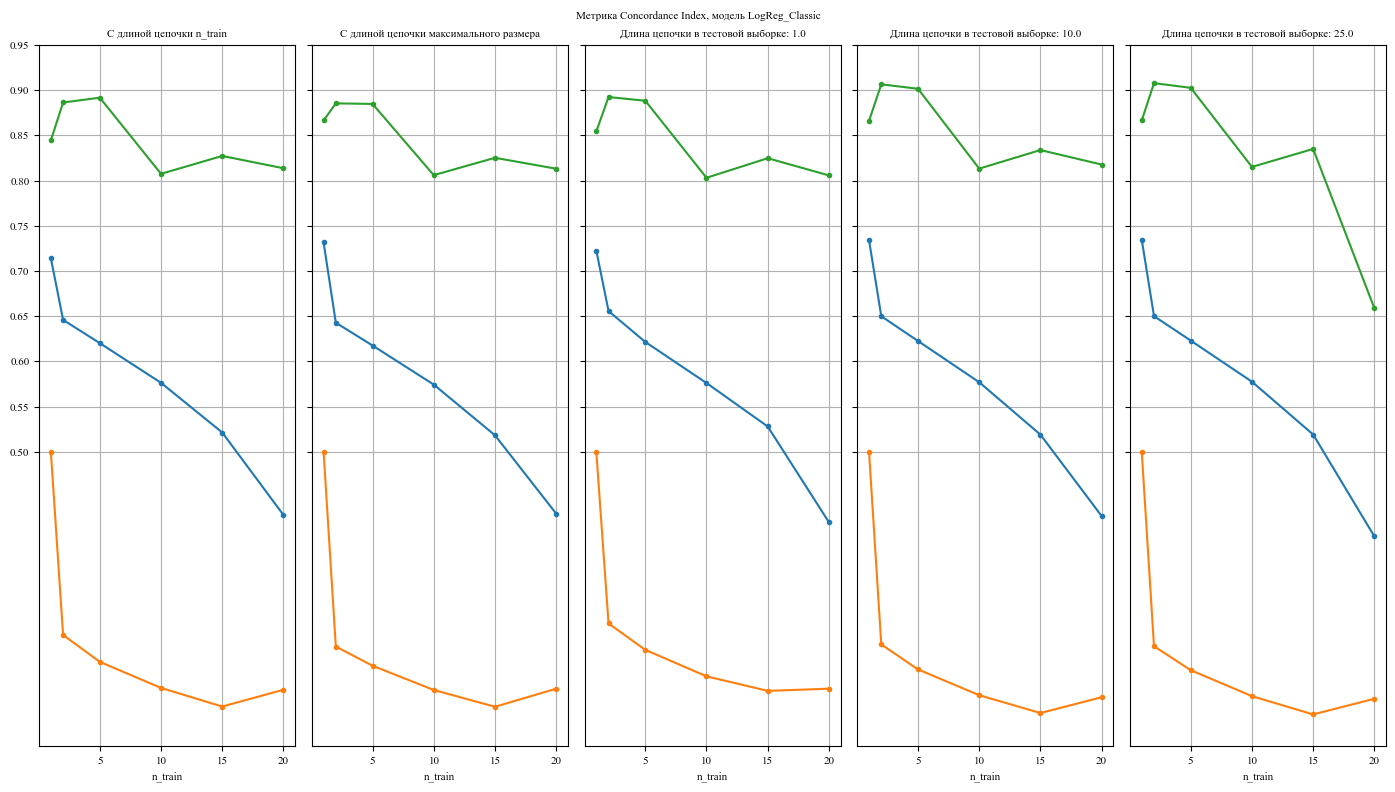

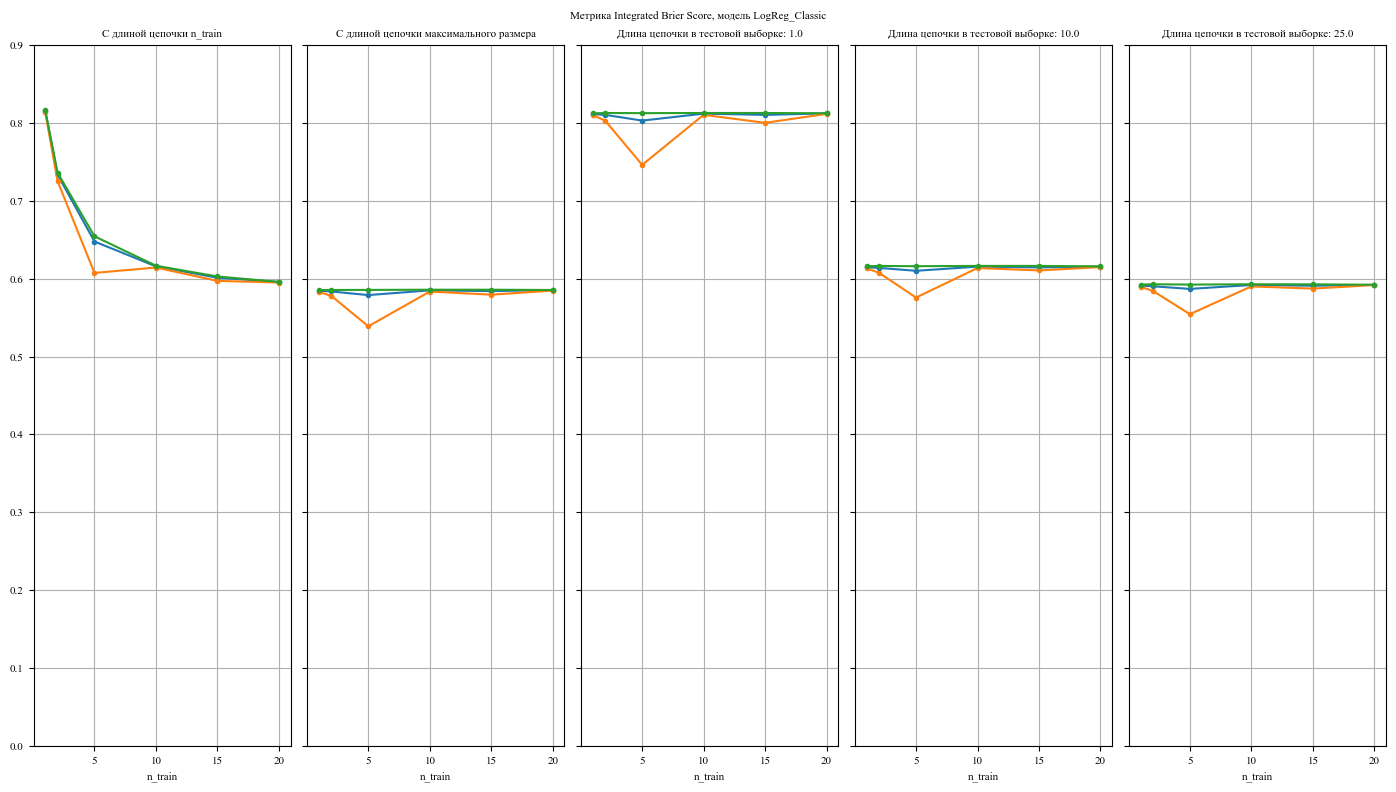

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (14,8)
plt.rcParams["font.family"] = "Times New Roman"
SMALL_SIZE = 6
MEDIUM_SIZE = 7
BIGGER_SIZE = 8

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
df_logreg = pd.read_csv('grid_search.csv')
draw_all_metrics_agg(df_logreg, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'LogReg_Classic')
draw_all_metrics_agg(df_logreg, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='LogReg_Classic')


In [ ]:
# from modules.constants import TEST_GRID

# for test_samples in TEST_GRID:
#     fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
#     fig.suptitle(f'test_samples={test_samples}')
#     draw_pandas_plot(df, 'ci_train_same_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples, ax = ax[0])
#     draw_pandas_plot(df, 'ci_train_max_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax = ax[1])
#     draw_pandas_plot(df, 'ci_test', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax=ax[2])
    
# for test_samples in TEST_GRID:
#     fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
#     fig.suptitle(f'test_samples={test_samples}')
#     draw_pandas_plot(df, 'ibs_train_same_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples, ax = ax[0])
#     draw_pandas_plot(df, 'ibs_train_max_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax = ax[1])
#     draw_pandas_plot(df, 'ibs_test', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax=ax[2])

: 

: 

In [ ]:
from modules.constants import TEST_GRID
for test_samples in TEST_GRID:
    fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
    fig.suptitle(f'test_samples={test_samples}')
    draw_pandas_plot(df, 'test_time', np.arange(0, 1250, 125), test_samples=test_samples, ax = ax)

: 

: 

In [ ]:
metric_df = df[df['test_samples'] == 1].groupby('train_samples')['train_time'].agg(['median'])
plt.plot(metric_df, marker='.')
plt.title('Время обучения')
plt.xlabel('Число наблюдений в цепочке')
plt.ylabel('Время обучения, с')

: 

: 

In [ ]:
from modules.constants import TEST_GRID
fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
fig.suptitle(f'Train time')
draw_pandas_plot(df, 'train_time', np.arange(0, 200, 50), test_samples=1, ax = ax)

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_pandas_plot(df, 'ci_train_same_size', np.arange(0.0, 1.1, 0.05), ax = ax[0])
draw_pandas_plot(df, 'ci_train_max_size', np.arange(0.0, 1.1, 0.05), ax = ax[1])
draw_pandas_plot(df, 'ci_test', np.arange(0.0, 1.1, 0.05), ax=ax[2])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_pandas_plot(df, 'ibs_train_same_size', np.arange(0.1, 0.3, 0.05), ax=ax[0])
draw_pandas_plot(df, 'ibs_train_max_size', np.arange(0.1, 0.3, 0.05), ax=ax[1])
draw_pandas_plot(df, 'ibs_test', np.arange(0.1, 0.3, 0.05), ax=ax[2])


: 

: 

In [ ]:
df_top = df.sort_values(by='ibs_train_same_size', ascending=True).groupby('train_samples').head(7)

: 

: 

In [ ]:
def draw_mean_plot(df, metric, ticks, test_samples=1, ax=None):
    metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[metric].agg(['mean'])
    if not ax is None:
        ax.plot(metric_df)
        ax.set_yticks(ticks)
        ax.set_ylabel(metric)
        return 0
    return plt.plot(metric_df)

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_mean_plot(df_top, 'ci_train_same_size', np.arange(0.7, 1, 0.05), ax=ax[0])
draw_mean_plot(df_top, 'ci_train_max_size', np.arange(0.7, 1, 0.05), ax=ax[1])
draw_mean_plot(df_top, 'ci_test', np.arange(0.7, 1, 0.05), ax=ax[2])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
draw_mean_plot(df_top, 'train_time', np.arange(0, 1000, 100), ax=ax)

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_mean_plot(df_top, 'ibs_train_same_size', np.arange(0.1, 0.50, 0.05), ax=ax[0])
draw_mean_plot(df_top, 'ibs_train_max_size', np.arange(0.1, 0.50, 0.05), ax=ax[1])
draw_mean_plot(df_top, 'ibs_test', np.arange(0.1, 0.50, 0.05), ax=ax[2])a

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=10')
draw_mean_plot(df_top, 'ibs_train_same_size', np.arange(0.1, 0.50, 0.05),test_samples=10, ax=ax[0])
draw_mean_plot(df_top, 'ibs_train_max_size', np.arange(0.1, 0.50, 0.05), test_samples=10,ax=ax[1])
draw_mean_plot(df_top, 'ibs_test', np.arange(0.1, 0.50, 0.05), test_samples=10,ax=ax[2])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle('test_samples=25')
draw_pandas_plot(df, 'ci_train', np.arange(0.4, 1.1, 0.05), test_samples=25, ax = ax[0])
draw_pandas_plot(df, 'ci_test', np.arange(0.4, 1.1, 0.05), test_samples=25, ax=ax[1])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle('test_samples=25')
draw_pandas_plot(df, 'ibs_train', np.arange(0.1, 1.1, 0.05), test_samples=25, ax = ax[0])
draw_pandas_plot(df, 'ibs_test', np.arange(0.1, 1.1, 0.05), test_samples=25, ax=ax[1])

: 

: 

In [ ]:
# import matplotlib.pyplot as plt
# def draw_all_metrics_plots(df, metric, ticks, full_metrics_name=None):
#     test_grid = df['test_samples'].dropna().unique()
#     test_grid_sz = len(test_grid)
    
#     fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
#     fig.suptitle(f'Метрика {full_metrics_name if not full_metrics_name is None else metric}')

#     metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean', 'min', 'max'])
#     metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean'])
#     ax[0].plot(metric_df, marker='.')
#     ax[0].set_yticks(ticks)
#     ax[0].set_xlabel('n_train')
#     # ax[0].set_title(f'С длиной цепочки n_train')

#     ax[0].grid()

#     metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean', 'min', 'max'])
#     metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean'])
#     ax[0].plot(metric_df, marker='.')
#     ax[0].set_yticks(ticks)
#     ax[0].set_title(f'C длиной цепочки максимального размера')
#     ax[0].set_xlabel('n_train')
#     ax[0].grid()
    
#     for i, test_samples in enumerate(test_grid):
#         metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean', 'min', 'max'])
#         metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean'])
#         ax[1].plot(metric_df, marker='.')
#         ax[1].set_xlabel('n_train')
#         ax[1].grid()
        
#         ax[1].set_yticks(ticks)
#     ax[1].set_title(f'Длина цепочки в тестовой выборке: {test_samples}')
#     ax[1].legend([1, 10, 25], title='Длина цепочки')
#     fig.savefig(f'fig_{metric}.jpg')

: 

: 

# Новая стратегия

In [ ]:
# def draw_new_plots(df, metric, ticks, agg_samples, test_samples):
#     metric_df = df[(df['test_samples'] == test_samples) & (df['agg_samples'] == agg_samples)]
#     for agg_n in agg_samples:
#         plt.plot()

: 

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

: 

: 

In [ ]:
df = pd.read_csv('Grid Search/Agg_new_last.csv', index_col=False)

: 

: 

In [ ]:
# df = df[df['test_samples'] == 1]

: 

: 

In [ ]:
# plt.plot(df['agg_samples'].unique(), df['ci_train'])

: 

: 

In [ ]:
# plt.plot(df['agg_samples'].unique(), df['ibs_train'])

: 

: 

In [ ]:
def draw_new_plot(df, metric):
    metric_df = df.groupby('agg_samples')[metric].agg(['mean', 'min', 'max'])
    plt.plot(metric_df)
    plt.title(metric)

: 

: 

In [ ]:
draw_new_plot(df, 'ci_train')

: 

: 

In [ ]:
draw_new_plot(df, 'ibs_train')

: 

: 

: 

: 